In [1]:
# Modelado
#import tensorflow as tf # no se requiere
#from tensorflow import keras # no se requiere
#from keras.models import Sequential # no se requiere
#from keras import Input # no se requiere
#from keras.layers import Dense, SimpleRNN # no se requiere
import neuralprophet

# procesamiento
import pandas as pd
import numpy as np
import json
# ml, procesamiento
#import sklearn
from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
# analisis series de tiempo
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # no se requiere
#from statsmodels.tsa.stattools import adfuller # no se requiere

# optimización, warnings
import optuna
import warnings
import optuna.visualization as vis
warnings.filterwarnings("ignore")

# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)
import arnet

c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [2]:
# carga de datos desde archivos csv
# se descomentan solo los de nvidia y syp 
tickets = [
    "NVDA",
    "^SPX"
    #"AMD",
    #"BTC-USD",
    #"^NDX",
    #"^VIX",
    #"UBSFY"
]
# se cargan las fechas
dates = pd.read_csv("../../data/csv/SPX_data.csv")
# se crea un dataframe con las fechas de close para almacenar los precios de cierre
date_close = pd.DataFrame({
    "Date": pd.to_datetime(dates["Date"])
})

# se recorren los tickets, se lee el archivo asociado al ticket y se
# carga en el df el precio de cierre

for ticket in tickets: 
    file_name = ticket.replace("^", "") # se quita el caracter ^
    data_ticket = pd.read_csv(f"../../data/csv/{file_name}_data.csv") # se lee el archivo csv del ticket correspondiente
    data_ticket["Date"] = pd.to_datetime(data_ticket["Date"]) # se formatea la columna Date a fecha

    # se define el nombre de la columna de precios de cierre
    close_column = f"{file_name}_Close"

    # se hace left join del df de las fechas con el df del ticket creado, por fechas
    date_close = pd.merge(
        date_close, # primer df
        data_ticket[["Date", close_column]].rename(columns={close_column: file_name}),
        # se escogen las columnas date y cierre del df del ticket y se renombra la columna de precio de cierre con el nombre del ticket
        on="Date", # columna para hacer el merge
        how="left" # tipo de merge
    )

In [3]:
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_dat_close = df_data_close.sort_values(by="Date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()

,Date,NVDA,SPX
0,2021-01-04,13.077454,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579826,3748.139893
3,2021-01-07,13.307321,3803.790039
4,2021-01-08,13.240253,3824.679932


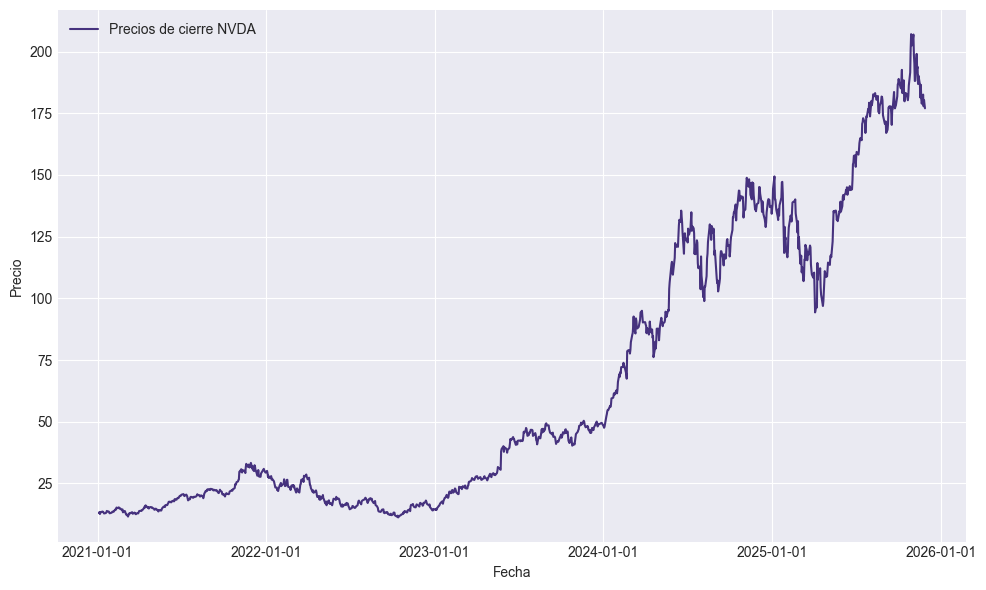

In [4]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(df_data_close["Date"], df_data_close["NVDA"], label="Precios de cierre NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [5]:
df_data_close = df_data_close.rename(columns={'Date': 'ds', 'NVDA': 'y'})
df = df_data_close
df.head()

,ds,y,SPX
0,2021-01-04,13.077454,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579826,3748.139893
3,2021-01-07,13.307321,3803.790039
4,2021-01-08,13.240253,3824.679932


In [6]:
# se hace una copia para la manipulación de los datos y se deja un porcentaje para extrapolar el comportamiento del modelo
df_data_close_copy = df_data_close.copy()
#forecast_size = 20 # porcentaje de datos para folds
percentage = 0.90
folds_data_size = int(len(df_data_close_copy) * percentage) # tamaño de los datos para folds
folds_data = df_data_close_copy.iloc[:folds_data_size] # datos para folds
val_data = df_data_close_copy.iloc[folds_data_size:] # datos para validación final

# se calcula la fecha donde se toman los datos de validación
#val_start_date = folds_data["Date"][-1:].values[0]
val_start_date = val_data["ds"].iloc[0]

#val_start_date["Date"] 

len(val_data)

124

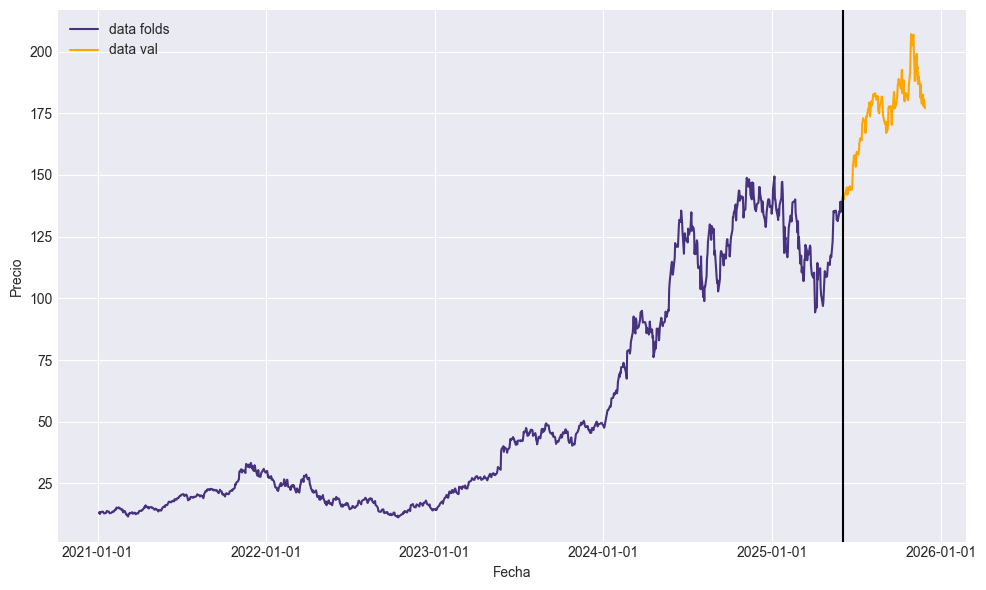

In [7]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(folds_data["ds"], folds_data["y"], label="data folds")
plt.plot(val_data["ds"], val_data["y"], label="data val", color='orange')
plt.axvline(val_start_date, color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [8]:
# visualización de los folds
# se muestra de forma visual como funcionan los folds para CTV
# si no se define el tamaño del test, en la primera iteración se toma igual cantidad de datos para train
# que para test
# por eso se toman los folds de prueba con longitud igual a los datos oos
size_test = int(len(val_data)) # tamaño datos oos

gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test

tscv = TimeSeriesSplit(
    n_splits=7,
    test_size= size_test,
    gap=0
)

# se crean los índices para los conjuntos de train y test
folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx))
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()
fig.add_trace(go.Scatter(
    x = indexes, 
    y=folds,
    mode='markers',
    marker=dict(
        color=['blue' if t == 'Train' else 'orange' for t in types],
        size=6
    ),
    text=types,
    hovertemplate='Indice: %{x} <br> Fold: %{y} Tipo: %{text} <extra></extra>'
))

fig.update_layout(
    title='Visualización de los folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)

fig.show()



In [9]:
for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(df)):
    train = df.iloc[train_idx].copy()
    test = df.iloc[test_idx].copy()
df

,ds,y,SPX
0,2021-01-04,13.077454,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579826,3748.139893
3,2021-01-07,13.307321,3803.790039
4,2021-01-08,13.240253,3824.679932
...,...,...,...
1228,2025-11-21,178.880005,6602.990234
1229,2025-11-24,182.550003,6705.120117
1230,2025-11-25,177.820007,6765.879883
1231,2025-11-26,180.259995,6812.609863


In [15]:
def objective(trial):

    df = folds_data[["ds", "y"]].copy()

    # -----------------------------
    # Hiperparámetros del modelo
    # -----------------------------
    params = {
        # ---- AR-Net ----
        "n_lags": trial.suggest_int("n_lags", 5, 40),
        "n_forecasts": len(val_data),   # multipaso directo

        # ---- tendencia ----
        "n_changepoints": trial.suggest_int("n_changepoints", 25, 300),
        "changepoints_range": trial.suggest_float("changepoints_range", 0.7, 0.95),

        # ---- regularización ----
        "trend_reg": trial.suggest_float("trend_reg", 0.0, 10.0),
        "seasonality_reg": trial.suggest_float("seasonality_reg", 0.0, 10.0),
        "ar_reg": trial.suggest_float("ar_reg", 0.0, 5.0),

        # ---- entrenamiento ----
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "epochs": trial.suggest_int("epochs", 50, 200),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),

        # ---- estacionalidades ----
        "yearly_seasonality": False,
        "weekly_seasonality": False,
        "daily_seasonality": False,

        # ---- otros ----
        "normalize": "auto",
        "loss_func": "Huber",
    }

    # -----------------------------
    # Validaciones estructurales
    # -----------------------------
    if params["n_lags"] >= len(df) - 1:
        raise optuna.TrialPruned()

    if len(val_data) > (len(df) - params["n_lags"]):
        raise optuna.TrialPruned()

    # -----------------------------
    # Modelo
    # -----------------------------
    model = neuralprophet.NeuralProphet(**params)
    model.add_country_holidays(country_name="US")

    model.fit(
        df,
        freq="B",
        progress="off"
    )

    # -----------------------------
    # Predicción multipaso directa
    # -----------------------------
    future_df = model.make_future_dataframe(
        df,
        periods=1,
        n_historic_predictions=False
    )

    forecast = model.predict(future_df)

    H = len(val_data)
    yhat_cols = [f"yhat{i+1}" for i in range(H)]

    y_pred = forecast[yhat_cols].iloc[-1].values



    # -----------------------------
    # Métrica (in-sample tail proxy)
    # -----------------------------
    # ⚠️ IMPORTANTE:
    # Aquí NO hay OOS real; esto es SOLO para Optuna.
    # La evaluación final debe hacerse fuera.
    y_true = df["y"].values[-len(val_data):]

    mape = mean_absolute_percentage_error(y_true, y_pred)

    return float(mape)


In [16]:
print("Optimización con Optuna")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)
best_params = study.best_params
print("Mejores parámetros encontrados: ", best_params)

[I 2025-12-25 22:43:58,043] A new study created in memory with name: no-name-6f0285f5-2c7a-4443-aee2-33a20b06fa09


Optimización con Optuna


INFO - (NP.config.__post_init__) - Note: Trend changepoint regularization is experimental.
INFO - (NP.config.__post_init__) - Note: Fourier-based seasonality regularization is experimental.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 96.032% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.data.processing._handle_missing_data) - Added 43 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 43 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 43 NaN values in column y were auto-imputed.
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |          | 0/? [03:24<?, ?it/s, v_num=31, train_loss=0.0345, reg_loss=0.0201, MAE=7.340, RMSE=12.20, Loss=0.0344, RegLoss=0.0201]

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 96.032% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 124.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 98.63% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 98.63% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.data.processing._handle_missing_data) - Added 1 missing dates.
INFO - (NP.data.processing._handle_missing_data) - Dropped 124 rows at the end with NaNs in 'y' column.
WARNING - (NP.data.processing._handle_missing_data) - 1 missing v


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 40.99it/s]


INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
[W 2025-12-25 22:47:24,588] Trial 0 failed with parameters: {'n_lags': 22, 'n_changepoints': 198, 'changepoints_range': 0.7258808846267055, 'trend_reg': 1.1065458753349144, 'seasonality_reg': 6.88665425242733, 'ar_reg': 2.100799799742581, 'learning_rate': 0.0008159431985965297, 'epochs': 167, 'batch_size': 32} because of the following error: ValueError('Input contains NaN.').
Traceback (most recent call last):
  File "c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\JUAN DAVID\AppData\Local\Temp\ipykernel_27436\1926507707.py", line 84, in objective
    mape = mean_absolute_percentage_error(y_true, y_pred)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesi

ValueError: Input contains NaN.

In [ ]:
results = model.predict(n_steps=len(val_data))
results"""  """

In [ ]:
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(val_data)], df_data_close["NVDA"][:-len(val_data)], label="Precio real NVDA - train", color="gray")
plt.plot(val_data["ds"], val_data["y"], label="Precio real NVDA")
plt.plot(val_data["ds"], results, label="Precio pronosticado NeuralProphet", color="orange")
plt.legend()
plt.show()